# Analisando investimentos

In [37]:
# Importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yfinance as yf
import math

In [38]:
# Lendo o arquivo
caminho = 'Arquivo_Basin.xlsx'
file = pd.ExcelFile(caminho)
abas = file.sheet_names
abas

['Bolsa Basin', 'valor_investido_vs_investimento', 'Compras']

In [39]:
contador = 0 
while contador < 3:
    for guia in abas:
        if contador == 0:
            df_precos = pd.read_excel(caminho,sheet_name=guia, engine = "openpyxl")
            contador += 1
        elif contador ==1:
            df_valor_investido_investimento = pd.read_excel(caminho,sheet_name=guia, engine = "openpyxl")
            contador += 1
        else:
            df_valor_compras = pd.read_excel(caminho,sheet_name=guia, engine = "openpyxl")
            contador += 1
    

In [40]:
df_precos

,Date,GOAU3.SA,WHRL4.SA,TAEE3.SA,CMIG3.SA,GGBR3.SA,CGRA3.SA,CPLE6.SA,UNIP6.SA,PATI4.SA,ROMI3.SA
0,2000-01-31,0.921254,0.283719,0.000000,0.486964,0.179640,0.000000,0.474200,19.425749,0.000000,0.149790
1,2000-02-29,0.223116,0.283719,0.000000,0.442694,0.189905,0.000000,0.522919,19.597649,0.000000,0.148427
2,2000-03-31,0.223116,0.232650,0.000000,0.486964,0.164242,0.000000,0.479072,24.067284,0.000000,0.148578
3,2000-04-30,0.217718,0.232650,0.000000,0.453762,0.179640,0.000000,0.433601,24.411140,0.000000,0.166602
4,2000-05-31,0.737003,0.232650,0.000000,0.464829,0.637166,0.000000,0.477448,0.817083,0.000000,0.166602
...,...,...,...,...,...,...,...,...,...,...,...
295,2024-08-31,10.426331,4.134343,11.544510,14.014286,15.958160,24.341160,10.037450,46.772297,37.318066,10.502937
296,2024-09-30,10.614102,4.457757,11.181598,14.385393,16.607908,23.631920,9.806483,46.129280,29.000000,10.566438
297,2024-10-31,10.050785,4.275612,11.367958,14.316328,17.582527,23.631920,9.600332,44.220005,31.500000,9.854204
298,2024-11-30,11.380000,4.122227,11.320000,14.799788,19.600000,23.830507,9.502470,52.000000,33.500000,9.024889


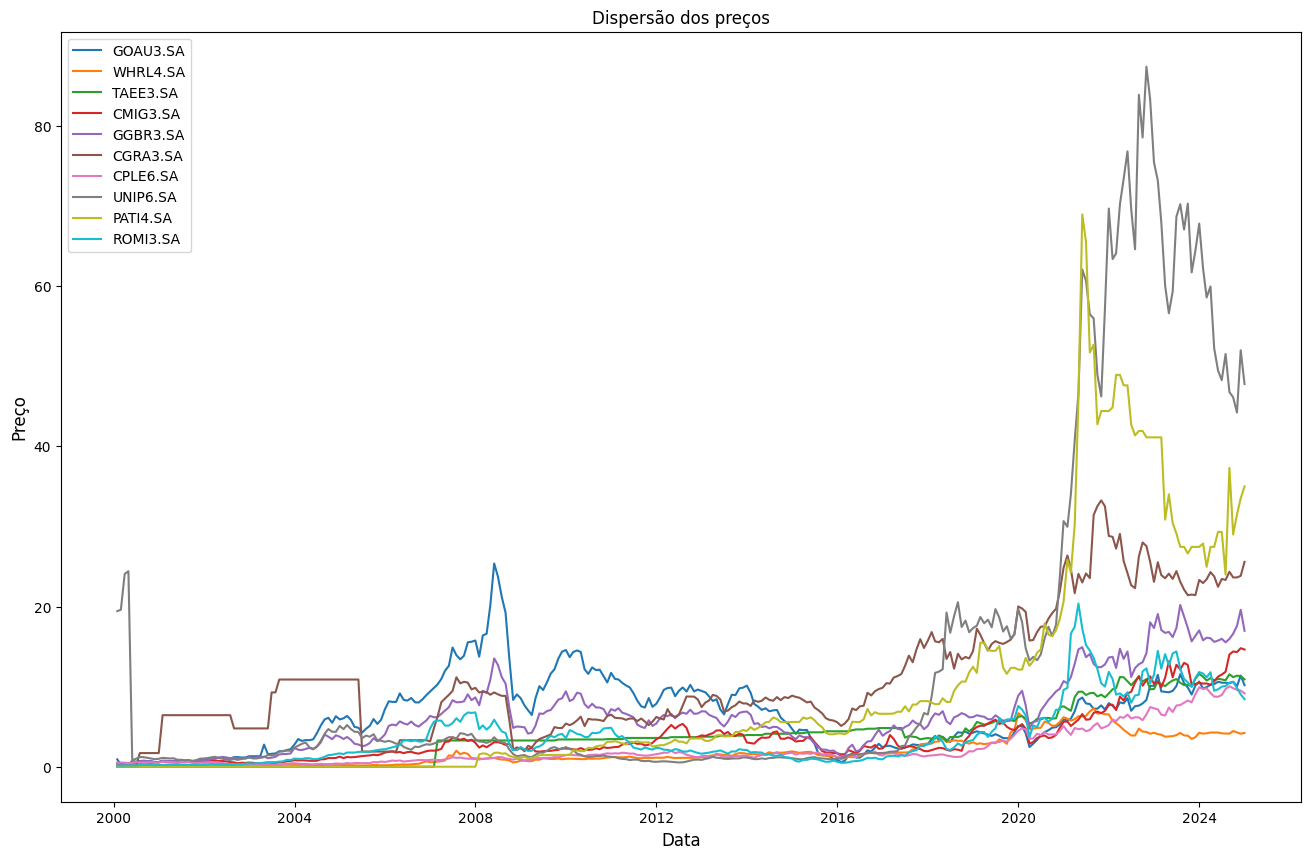

In [41]:
df_precos['Date'] = pd.to_datetime(df_precos['Date'])

plt.figure(figsize=(16,10))
# Para plotar n precisa criar dicionario ou algo do gerando o proprio plt vai implementando
for coluna in df_precos.columns[1:]:
    plt.plot(df_precos['Date'], df_precos[coluna], label=coluna)
plt.title('Dispersão dos preços', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço', fontsize=12)
plt.legend(loc='upper left', fontsize=10) 
plt.show()

# oq eu preciso fazer
 - Preciso dos desvios padrões dos ativos
 - retono dos ativos
 - Preciso da correlação entre os ativos, descorbrir um jeito de calcular
 - preciso pegar o valor da ultima linha do preco de cada ativo para calcular o valor da carteira
- Com o valor carteira determinar o percentual de cada ativo na carteira e calcular o retorno esperado
- Depois calcular o risco do portifolio defir uma função que faça isso
- retorno esperado
Calcular o indice sharp , utilizando inflação e selic media
- Calcular a renda anual que a carteira teria
Calcular o ganho de capital
retorno levar em consideração o retorno logaritimo pegar no livro do assaf neto depois (TCC escrito)


In [42]:
array = np.array([df_precos[acao].values for acao in df_precos.columns[1:]])
df_precos.set_index('Date', inplace=True)

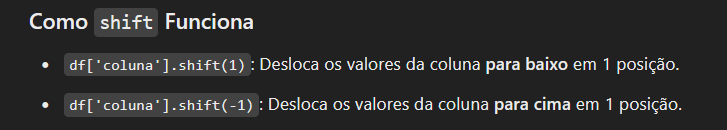

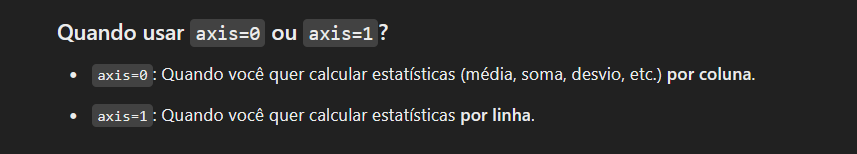

In [43]:
desvio_padro = np.std(array, axis=1)
desvio_padro

array([ 4.48286886,  1.79419006,  3.36296819,  3.220616  ,  4.6394552 ,
        7.52083102,  2.39128908, 21.89403254, 13.69883104,  3.94442827])

In [44]:
# Ver quantos meses cada acao ficou em negociação para, para definir o retorno anual
dict_ano_negociado = {}
for acao in df_valor_compras['Acao']:
    dict_ano_negociado[acao]= (df_precos[df_precos[acao]!=0][acao].count())/12
dict_ano_negociado

{'GOAU3.SA': np.float64(25.0),
 'WHRL4.SA': np.float64(25.0),
 'TAEE3.SA': np.float64(17.916666666666668),
 'CMIG3.SA': np.float64(25.0),
 'GGBR3.SA': np.float64(25.0),
 'CGRA3.SA': np.float64(24.5),
 'CPLE6.SA': np.float64(25.0),
 'UNIP6.SA': np.float64(25.0),
 'PATI4.SA': np.float64(17.0),
 'ROMI3.SA': np.float64(25.0)}

In [45]:
dict_retornos = {}
for acao in df_valor_compras['Acao']:
    retorno_logaritimo_soma = np.log(df_precos[acao].replace(0,np.nan)/df_precos[acao].replace(0,np.nan).shift(1)).sum()
    vezes_multi_capital = np.exp(retorno_logaritimo_soma)-1
    retorno_anual = (1+vezes_multi_capital)**(1/dict_ano_negociado[acao])-1
    dict_retornos[acao]= retorno_anual*100
dict_retornos

{'GOAU3.SA': np.float64(10.086670684682097),
 'WHRL4.SA': np.float64(11.403015221480327),
 'TAEE3.SA': np.float64(6.942926702328389),
 'CMIG3.SA': np.float64(14.580285325754216),
 'GGBR3.SA': np.float64(19.953015944103747),
 'CGRA3.SA': np.float64(11.691011995864354),
 'CPLE6.SA': np.float64(12.568884972874761),
 'UNIP6.SA': np.float64(3.6656164590280094),
 'PATI4.SA': np.float64(20.133358397449676),
 'ROMI3.SA': np.float64(17.499052551957472)}

In [46]:
# Calcular correlações
df_corre = df_precos[[colunas for colunas in df_precos.columns if colunas != 'Date']].replace(0,np.nan)
df_corre

,GOAU3.SA,WHRL4.SA,TAEE3.SA,CMIG3.SA,GGBR3.SA,CGRA3.SA,CPLE6.SA,UNIP6.SA,PATI4.SA,ROMI3.SA
Date,,,,,,,,,,
2000-01-31,0.921254,0.283719,NaN,0.486964,0.179640,NaN,0.474200,19.425749,NaN,0.149790
2000-02-29,0.223116,0.283719,NaN,0.442694,0.189905,NaN,0.522919,19.597649,NaN,0.148427
2000-03-31,0.223116,0.232650,NaN,0.486964,0.164242,NaN,0.479072,24.067284,NaN,0.148578
2000-04-30,0.217718,0.232650,NaN,0.453762,0.179640,NaN,0.433601,24.411140,NaN,0.166602
2000-05-31,0.737003,0.232650,NaN,0.464829,0.637166,NaN,0.477448,0.817083,NaN,0.166602
...,...,...,...,...,...,...,...,...,...,...
2024-08-31,10.426331,4.134343,11.544510,14.014286,15.958160,24.341160,10.037450,46.772297,37.318066,10.502937
2024-09-30,10.614102,4.457757,11.181598,14.385393,16.607908,23.631920,9.806483,46.129280,29.000000,10.566438
2024-10-31,10.050785,4.275612,11.367958,14.316328,17.582527,23.631920,9.600332,44.220005,31.500000,9.854204


In [47]:
correlacao = df_corre.corr()
correlacao

,GOAU3.SA,WHRL4.SA,TAEE3.SA,CMIG3.SA,GGBR3.SA,CGRA3.SA,CPLE6.SA,UNIP6.SA,PATI4.SA,ROMI3.SA
GOAU3.SA,1.000000,0.121798,-0.013708,0.375866,0.643160,0.100306,0.259302,0.183195,0.003161,0.452823
WHRL4.SA,0.121798,1.000000,0.768879,0.717042,0.727740,0.897542,0.788083,0.760983,0.836712,0.806099
TAEE3.SA,-0.013708,0.768879,1.000000,0.919064,0.828406,0.884829,0.960481,0.948134,0.899718,0.820661
CMIG3.SA,0.375866,0.717042,0.919064,1.000000,0.894765,0.785018,0.947214,0.852164,0.758218,0.796364
GGBR3.SA,0.643160,0.727740,0.828406,0.894765,1.000000,0.760750,0.866679,0.813804,0.763522,0.901576
CGRA3.SA,0.100306,0.897542,0.884829,0.785018,0.760750,1.000000,0.833137,0.876545,0.904528,0.812414
CPLE6.SA,0.259302,0.788083,0.960481,0.947214,0.866679,0.833137,1.000000,0.883411,0.791618,0.822562
UNIP6.SA,0.183195,0.760983,0.948134,0.852164,0.813804,0.876545,0.883411,1.000000,0.927782,0.848031
PATI4.SA,0.003161,0.836712,0.899718,0.758218,0.763522,0.904528,0.791618,0.927782,1.000000,0.861204
ROMI3.SA,0.452823,0.806099,0.820661,0.796364,0.901576,0.812414,0.822562,0.848031,0.861204,1.000000


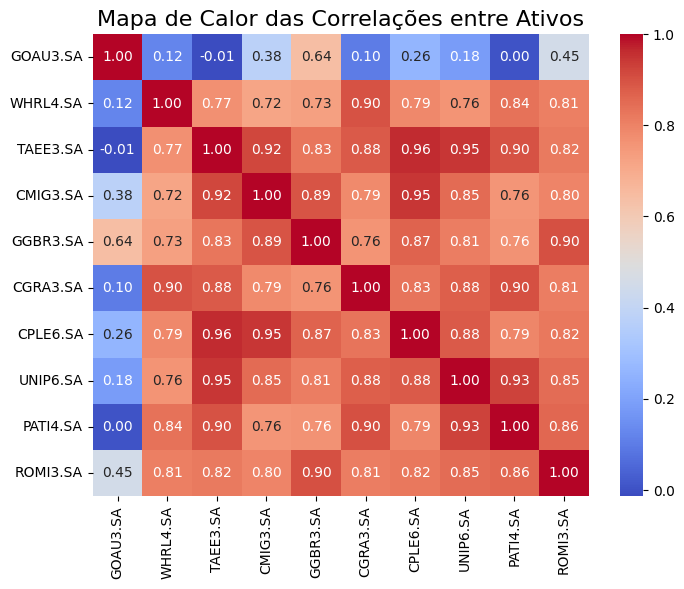

In [48]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)

# Personalizando o gráfico
plt.title('Mapa de Calor das Correlações entre Ativos', fontsize=16)
plt.show()

In [49]:
desvio_padro

array([ 4.48286886,  1.79419006,  3.36296819,  3.220616  ,  4.6394552 ,
        7.52083102,  2.39128908, 21.89403254, 13.69883104,  3.94442827])

In [50]:
dict_desvio = {acao:0 for acao in df_valor_compras['Acao']}
contador = 0
for acao in df_valor_compras['Acao']:
    dict_desvio[acao]= desvio_padro[contador]
    contador +=1
dict_desvio

{'GOAU3.SA': np.float64(4.4828688555644245),
 'WHRL4.SA': np.float64(1.7941900596204858),
 'TAEE3.SA': np.float64(3.362968193078038),
 'CMIG3.SA': np.float64(3.2206160042984866),
 'GGBR3.SA': np.float64(4.639455203071308),
 'CGRA3.SA': np.float64(7.520831017525515),
 'CPLE6.SA': np.float64(2.3912890755899108),
 'UNIP6.SA': np.float64(21.89403253585683),
 'PATI4.SA': np.float64(13.698831042882382),
 'ROMI3.SA': np.float64(3.9444282693820276)}

In [51]:
df_precos_final = df_precos[[colunas for colunas in df_precos.columns if colunas != 'Date']].tail(1)
df_precos_final

,GOAU3.SA,WHRL4.SA,TAEE3.SA,CMIG3.SA,GGBR3.SA,CGRA3.SA,CPLE6.SA,UNIP6.SA,PATI4.SA,ROMI3.SA
Date,,,,,,,,,,
2024-12-31,10.18,4.22,10.91,14.63,16.969999,25.58,9.15,47.779999,35.0,8.44


In [52]:
dict_valor_ativo = {}
contador = 0
while contador < len(df_valor_compras):
    acao = qtd=df_valor_compras.loc[contador,'Acao']
    qtd=df_valor_compras.loc[contador,'Qtd_comprada']
    dict_valor_ativo[acao]=qtd
    contador += 1
dict_valor_ativo
        

{'GOAU3.SA': np.int64(399),
 'WHRL4.SA': np.int64(707),
 'TAEE3.SA': np.int64(359),
 'CMIG3.SA': np.int64(535),
 'GGBR3.SA': np.int64(445),
 'CGRA3.SA': np.int64(331),
 'CPLE6.SA': np.int64(525),
 'UNIP6.SA': np.int64(352),
 'PATI4.SA': np.int64(174),
 'ROMI3.SA': np.int64(368)}

In [53]:
valor_total = 0
porcentagem_ativo = {}
for acao in dict_valor_ativo.keys():
    preco = df_precos_final[acao].values
    qtd = dict_valor_ativo[acao]
    valor_total += preco*qtd
print(valor_total)


[65625.95886469]


In [54]:
porcentagem_ativo = {}
for acao in dict_valor_ativo.keys():
    preco = df_precos_final[acao].values
    qtd = dict_valor_ativo[acao]
    porcentagem_ativo[acao]= (preco*qtd)/valor_total
porcentagem_ativo

{'GOAU3.SA': array([0.0618935]),
 'WHRL4.SA': array([0.0454628]),
 'TAEE3.SA': array([0.05968202]),
 'CMIG3.SA': array([0.11926759]),
 'GGBR3.SA': array([0.11507108]),
 'CGRA3.SA': array([0.12901876]),
 'CPLE6.SA': array([0.07319893]),
 'UNIP6.SA': array([0.25627907]),
 'PATI4.SA': array([0.09279864]),
 'ROMI3.SA': array([0.04732761])}

In [55]:
def variancia_risco_port(participacao_1,participacao_2,delta_1,delta_2,corr_1_2):
    variancia = participacao_1*participacao_2*delta_1*delta_2*corr_1_2
    return variancia

In [56]:
correlacao

,GOAU3.SA,WHRL4.SA,TAEE3.SA,CMIG3.SA,GGBR3.SA,CGRA3.SA,CPLE6.SA,UNIP6.SA,PATI4.SA,ROMI3.SA
GOAU3.SA,1.000000,0.121798,-0.013708,0.375866,0.643160,0.100306,0.259302,0.183195,0.003161,0.452823
WHRL4.SA,0.121798,1.000000,0.768879,0.717042,0.727740,0.897542,0.788083,0.760983,0.836712,0.806099
TAEE3.SA,-0.013708,0.768879,1.000000,0.919064,0.828406,0.884829,0.960481,0.948134,0.899718,0.820661
CMIG3.SA,0.375866,0.717042,0.919064,1.000000,0.894765,0.785018,0.947214,0.852164,0.758218,0.796364
GGBR3.SA,0.643160,0.727740,0.828406,0.894765,1.000000,0.760750,0.866679,0.813804,0.763522,0.901576
CGRA3.SA,0.100306,0.897542,0.884829,0.785018,0.760750,1.000000,0.833137,0.876545,0.904528,0.812414
CPLE6.SA,0.259302,0.788083,0.960481,0.947214,0.866679,0.833137,1.000000,0.883411,0.791618,0.822562
UNIP6.SA,0.183195,0.760983,0.948134,0.852164,0.813804,0.876545,0.883411,1.000000,0.927782,0.848031
PATI4.SA,0.003161,0.836712,0.899718,0.758218,0.763522,0.904528,0.791618,0.927782,1.000000,0.861204
ROMI3.SA,0.452823,0.806099,0.820661,0.796364,0.901576,0.812414,0.822562,0.848031,0.861204,1.000000


In [57]:
variacia_port = 0
for acao_1 in df_valor_compras['Acao']:
    for acao_2 in df_valor_compras['Acao']:
        participacao_1 = porcentagem_ativo[acao_1]
        participacao_2 = porcentagem_ativo[acao_2]
        desv_padro_1 = dict_desvio[acao_1]
        desv_padro_2 = dict_desvio[acao_2]
        corre = correlacao.loc[acao_1,acao_2]
        variacia_port +=variancia_risco_port(participacao_1,participacao_2,desv_padro_1,desv_padro_2,corre)
desv_pad_port=variacia_port**(1/2)
desv_pad_port

array([9.09841526])

# Quando se junta 2 arrays em um terceiro eles apenas pegam cada array e transforma numa dimensaõ de um terceiro, para juntar 2 arrays em 1 só é necessario concatenar
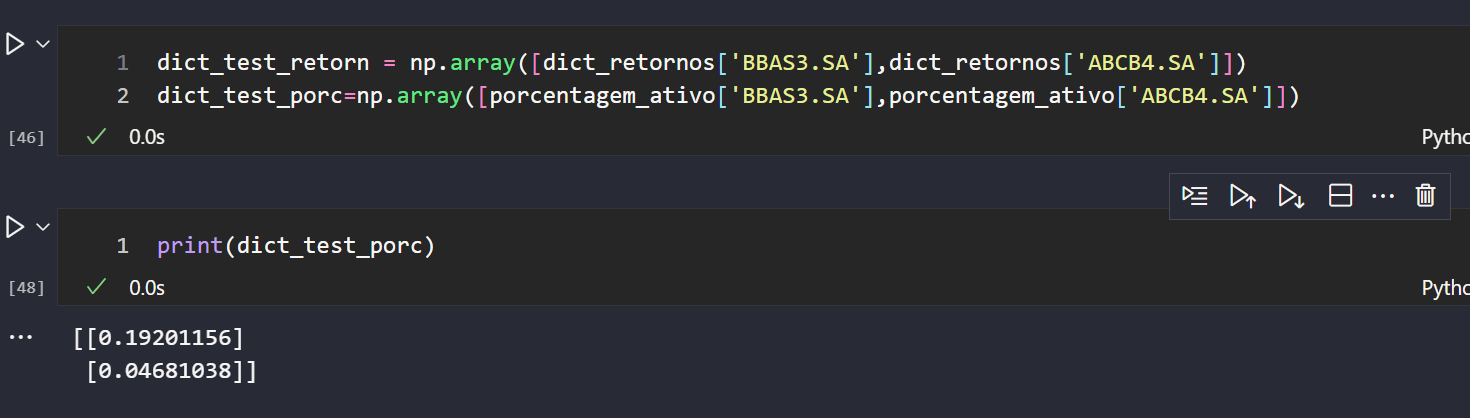

In [58]:
retornos = np.array([dict_retornos[acao] for acao in dict_retornos.keys()])
porcentagens=np.concatenate([porcentagem_ativo[acao] for acao in porcentagem_ativo.keys()])

In [59]:
print(retornos,porcentagens)

[10.08667068 11.40301522  6.9429267  14.58028533 19.95301594 11.691012
 12.56888497  3.66561646 20.1333584  17.49905255] [0.0618935  0.0454628  0.05968202 0.11926759 0.11507108 0.12901876
 0.07319893 0.25627907 0.09279864 0.04732761]


In [60]:
retorno_esperado = sum(retornos*porcentagens)
retorno_esperado

np.float64(11.656397038345629)

In [61]:
df_valor_investido_investimento

,Nome,Valor
0,carteira_contabil_basin,14968.985646
1,valor_investido_basin,14973.120000


In [62]:
Total_capital_faltou_investir = df_valor_investido_investimento.loc[1,'Valor',] - df_valor_investido_investimento.loc[0,'Valor',] 
Total_capital_faltou_investir

np.float64(4.134353796849609)

In [63]:
ganho_capital = valor_total - df_valor_investido_investimento.loc[1,'Valor',]
ganho_capital

array([50652.83886469])

In [64]:
contador = 0
valor_recebido_total = 0
while contador < len(df_valor_compras):
    for acao in df_valor_compras['Acao']:
        empresa = yf.Ticker(acao)
        dividendos = empresa.dividends
        if not dividendos.empty:
            dividendos_anuais_geral = dividendos.groupby(dividendos.index.year).sum()
            dividendo_ultimo_ano = dividendos_anuais_geral.tail(1)
            valor_pago = df_valor_compras.loc[contador, 'Qtd_comprada'] * dividendo_ultimo_ano.values
            valor_recebido_total+= valor_pago
            print(dividendo_ultimo_ano,valor_pago)
        else:
            valor_pago = 0  
        contador +=1
        

Date
2024    0.45
Name: Dividends, dtype: float64 [179.55]
Date
2024    0.417442
Name: Dividends, dtype: float64 [295.131494]
Date
2024    1.177485
Name: Dividends, dtype: float64 [422.717115]
Date
2024    1.384902
Name: Dividends, dtype: float64 [740.92257]
Date
2024    0.783333
Name: Dividends, dtype: float64 [348.583185]
Date
2024    2.686184
Name: Dividends, dtype: float64 [889.126904]
Date
2024    0.424496
Name: Dividends, dtype: float64 [222.8604]
Date
2024    1.559657
Name: Dividends, dtype: float64 [548.999264]
Date
2024    7.121479
Name: Dividends, dtype: float64 [1239.137346]
Date
2024    0.804286
Name: Dividends, dtype: float64 [295.977248]


In [65]:
SELIC_MEDIA = 12.15999870500932
DESV_PAD_SELIC = 4.793701588763131
INFLACAO = 6.18

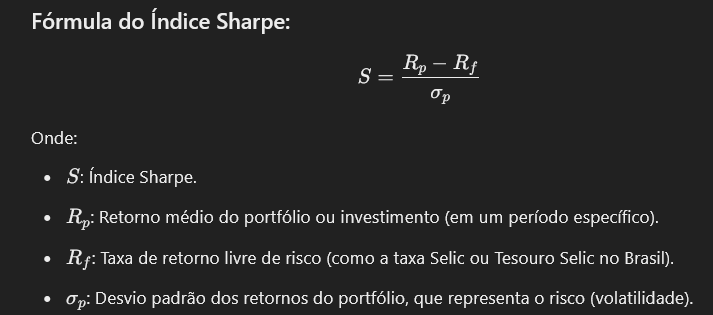

In [66]:
indice_sharpe_inflação = (retorno_esperado - INFLACAO)/desv_pad_port
indice_sharpe_inflação

print(f'Oferece um retorono de {indice_sharpe_inflação} para cada unidade de risco assumido')

Oferece um retorono de [0.60190669] para cada unidade de risco assumido


In [70]:
# Para taxa que sofre grandes variações pode se considerar o desvio padrao desse retorno no indice sharpe
# Devido a cenario de economia emergente e longo prazo gera essa variação

indice_sharpe_selic = (retorno_esperado-SELIC_MEDIA)/desv_pad_port[0]
indice_sharpe_selic
print(f'Oferece um retorono de {indice_sharpe_selic} para cada unidade de risco assumido')

Oferece um retorono de -0.05535048165240673 para cada unidade de risco assumido


tk inter
variavel de ambiente

In [71]:
dados = {'risco_portifolio':desv_pad_port, 'Retorno_portifolio':retorno_esperado,
         'Indice_sharpe_inflacao':indice_sharpe_inflação,
         'indice_sharpe_selic':indice_sharpe_selic, 'Dividendos':valor_recebido_total
         ,'ganho_capital':ganho_capital}
dados_df=pd.DataFrame(dados)

In [72]:
with pd.ExcelWriter('base_analise_basin.xlsx',engine='openpyxl') as writer:
        dados_df.to_excel(writer,sheet_name='Analise', index=False)
